# Árboles de decisión con el dataset `tennis.csv`

## Importación de librerías y el dataset `tennis.csv`

Se importan principalmente solo dos librerías las cuales son: `pandas` y `numpy` con sus alias "pd" y "np" respectivamente. Estas dos nos ayudan a manejar el dataset y realizar operaciones matemáticas.

Luego, se importan las librerías `networkx` y `matplotlib.pyplot` con sus alias "nx" y "plt" respectivamente junto a `train_test_split` de `sklearn.model_selection` y `confusion_matrix`, `ConfusionMatrixDisplay` y `classification_report` de `sklearn.metrics`. Estas dos primeras nos ayudan con el manejo de gráficos, mientras que las últimas nos ayudan a particionar el dataset en los datos de entrenamiento y de evaluación y también el manejo de métricas.

In [1]:
import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Luego se importará el dataset `tennis.csv` de manera habitual y este se guardará en el DataFrame `tennis`.

In [2]:
tennis = pd.read_csv('./tennis.csv')
tennis

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


## Creación de las particiones

Al igual que con cualquier otro dataset, se toman las características para `X` y las etiquetas para `Y`, esto con base en el DataFrame `tennis`.

In [3]:
X = tennis[tennis.columns[0:4]] # Características o features
Y = tennis['play'] # Etiquetas o labels

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42) # Separación en conjuntos de train y test

Debido a que en este caso no es de interés tener aparte `X_train` y `Y_train`, usamos el método `.merge()` para unirlos respetando el indexado para tener la unión correspondida.

In [4]:
df = pd.merge(X_train, Y_train, left_index=True, right_index=True, how='inner')  # Fusionar basado en el índice
df

,outlook,temp,humidity,windy,play
8,sunny,cool,normal,False,yes
2,overcast,hot,high,False,yes
1,sunny,hot,high,True,no
13,rainy,mild,high,True,no
4,rainy,cool,normal,False,yes
7,sunny,mild,high,False,no
10,sunny,mild,normal,True,yes
3,rainy,mild,high,False,yes
6,overcast,cool,normal,True,yes


## Implementación del método manualmente

Debido a que se busca implementar el método de forma manual, se crean un conjunto de funciones las cuales nos ayudarán en todos los cálculos a realizar junto con la organización. La explicación de las funciones es la siguiente:
- `custom_log2(x)`: esta función evita las indeterminaciones cuando se usa $\log_{2}{0}$, así, cuando es el caso sencillamente se reemplaza por $0$.
- `info_play(df)`: esta función calcula la entropía o información para la columna de las etiquetas "play", como esta siempre será fija entonces sencillamente se llama, sin embargo quién no será fijo es el DataFrame a usar por lo que hay que identificarlo en la variable `df` del argumento de la función.
- `info(features,df)`: esta función calcula la entropía o información para las columnas de las características, en ese sentido ya que calcula independientemente por cada característica que se tenga hay que identificar dicha columna en la variable `features` junto al DataFrame que se vaya a usar en la variable `df` del argumento de la función.
- `ganancia(df)`: esta función realiza el cálculo de la ganancia lo que sería la operación `info_play(df)` - `info(features,df)`, luego lo guarda en un array de dos columnas, donde en la primera se encuentra el nombre de la columna y en la segunda su ganancia correspondiente a su vez cabe destacar que las devuelve en orden de mayor a menor. Al igual que en las anteriores funciones hay que identificar el DataFrame que se vaya a usar en la variable `df` del argumento de la función.
- `decision(df)`: finalmente esta función lo que hace es realizar los respectivos cálculos previos pero ahora teniendo en cuenta la columna con la mayor ganancia que se obtiene de la función `ganancia(df)`, así obtiene resultados para ciertas características de dicha columna con mayor ganancia y si no, realiza el cálculo de las ganancias de las columnas restantes que correspondan a la característica a evaluar, de esta manera se obtendría la primera rama del árbol. Al ejecutar este comando repetidamente pero cambiando el DataFrame teniendo en cuenta cada nueva rama razón por la cual no solo esta función sino que todas las anteriores piden el DataFrame a usar como atributo.

In [5]:
def custom_log2(x):
    if x == 0:
        return 0
    else:
        return np.log2(x)
    
def info_play(df):
    play_matrix = df['play'].value_counts().to_numpy() # Extrae los valores y los transforma en una matriz para un mejor uso

    return -(play_matrix[0]/df['play'].count()) * custom_log2(play_matrix[0]/df['play'].count()) - (play_matrix[1]/df['play'].count()) * custom_log2(play_matrix[1]/df['play'].count()) # Realiza el cálculo info[#yes,#no]

def info(features,df):
    frecuencia_datos = df[features].value_counts().sort_index().values # Obtiene que tantas veces aparece cada característica en cada columna
    matriz = df.groupby([features, 'play']).size().unstack().fillna(0).sort_index().values # Cuenta cuántos de ellos van con un "yes" o un "no" en la columna "play"
    entropy_total = 0 # Inicia el cálculo final de entropía
    for i in range(len(frecuencia_datos)):
        entropy = -(matriz[i][0]/frecuencia_datos[i]) * custom_log2(matriz[i][0]/frecuencia_datos[i]) - (matriz[i][1]/frecuencia_datos[i]) * custom_log2(matriz[i][1]/frecuencia_datos[i]) # Calcula la entropía de cada característica
        entropy_total += entropy * frecuencia_datos[i]/df[features].count() # Suma todas las características para obtener el valor final
    return entropy_total # Devuelve dicho valor final

def ganancia(df):
    ganancia_matrix = [] # Crea la matriz que tendrá las ganancias de cada columna
    for i in range(df.shape[1] - 1):
        ganancia_matrix.append([df.columns[:-1].tolist()[i], info_play(df) - info(df.columns[:-1].tolist()[i],df)]) # Guarda la operación para calcular la ganancia de cada columna de la forma (columna,ganancia)
    return sorted(ganancia_matrix, key=lambda x: x[1], reverse=True) # Devuelve la matriz creada pero organizada de mayor a menor por la ganancia

def decision(df):
    columna = ganancia(df) # Guarda la matriz generada con las ganancias
    items = df[columna[0][0]].unique() # Guarda en un array la cantidad de datos únicos que tenga la ganancia más grande, es decir, la primera

    for i in range(len(items)):
        df_ = df.drop(df[df[columna[0][0]] != items[i]].index) # Elimina del DataFrame todos aquellos que no sean cierta característica
        df_ = df_.drop(columna[0][0], axis=1) # Elimina la columna que tiene la mayor ganancia
        
        if (len(df_['play'].value_counts().to_numpy()) == 1): # Si solo hay "yes" o "no", devuelve el resultado respectivo a la característica
            print('Para la característica "',items[i],'" el resultado es "',df_['play'].unique()[0],'".',sep="")
        else: # Si no, calcula las nuevas ganancias para esa característica y las muestra
            print('Para la característica "',items[i],'" se obtuvieron las siguientes ganancias:',sep="")
            for j in range(len(ganancia(df_))):
                print('  - Para la columna "',ganancia(df_)[j][0],'": ',ganancia(df_)[j][1],sep="")

Tras haber explicado cual es el uso de las diferentes funciones creadas, es hora de aplicarlas. Usando la función `ganancia()` obtenemos las ganancias de las diferentes columnas para el conjunto de entrenamiento completo.

In [6]:
print('Las ganancias de todas las columnas son:',sep="")

for i in range(len(ganancia(df))):
    print('  - Para la columna "',ganancia(df)[i][0],'": ',ganancia(df)[i][1],sep="")

Las ganancias de todas las columnas son:
  - Para la columna "humidity": 0.3788788371352292
  - Para la columna "temp": 0.2516291673878229
  - Para la columna "outlook": 0.16775277825854862
  - Para la columna "windy": 0.07278022578373278


De acá nos podemos dar cuenta que la columna con mayor ganancia es "humidity" por lo que será la que usaremos para la primera rama, esto el código lo identifica automáticamente por lo que ahora usaremos la función `decision()`.

In [7]:
decision(df)

Para la característica "normal" el resultado es "yes".
Para la característica "high" se obtuvieron las siguientes ganancias:
  - Para la columna "outlook": 0.5709505944546686
  - Para la columna "windy": 0.4199730940219748
  - Para la columna "temp": 0.01997309402197478


Así, nos damos cuenta que para la característica "normal" su resultado será "yes", de esta manera se realizará el mismo proceso para la característica "high" por lo que se modifica el dataframe original.

In [8]:
if 'humidity' in df.columns: # Identifica si la columna existe, así no arroja error si se vuelve a ejecutar
    df = df.drop(df[df['humidity'] != "high"].index)
    df = df.drop('humidity', axis=1)
df

,outlook,temp,windy,play
2,overcast,hot,False,yes
1,sunny,hot,True,no
13,rainy,mild,True,no
7,sunny,mild,False,no
3,rainy,mild,False,yes


Tras haber modificado el DataFrame con solo las columnas y características correspondientes a "high" y como la función `decision()` anterior ya nos arrojó el orden de las ganancias, no es necesario volver a usar la función `ganancia()`, simplemente volviendo a llamar a `decision()` con el DataFrame modificado basta.

In [9]:
decision(df)

Para la característica "overcast" el resultado es "yes".
Para la característica "sunny" el resultado es "no".
Para la característica "rainy" se obtuvieron las siguientes ganancias:
  - Para la columna "windy": 1.0
  - Para la columna "temp": 0.0


Así, obtenemos dos nuevos resultados en este caso para las características "overcast" y "sunny". En el caso de "rainy" se obtiene algo particular y es que sus ganancias para las columnas faltantes muestra que "windy" tiene una ganancia de 1.0 y "temp" de 0.0, lo que significa que la columna "windy" tiene la pureza máxima o lo que es igual a que las características son correspondientes, no obstante igualmente se obtendrán sus valores de ganancia o sus resultados directos.

Modificando nuevamente el dataset pero ahora para tener solo "rainy".

In [10]:
if 'outlook' in df.columns: # Identifica si la columna existe, así no arroja error si se vuelve a ejecutar
    df = df.drop(df[df['outlook'] != "rainy"].index)
    df = df.drop('outlook', axis=1)
df

,temp,windy,play
13,mild,True,no
3,mild,False,yes


Al igual que antes, solo se llama a la función `decision(df)`.

In [11]:
decision(df)

Para la característica "True" el resultado es "no".
Para la característica "False" el resultado es "yes".


Aunque solo con imprimir el DataFrame modificado ya se podía ver dicha correspondencia, no sobraba el volver a usar la función creada y rectificar los datos.

Con esto ya se tienen los datos suficientes para las diferentes ramas del árbol de decisión, las cuáles quedarían organizadas de la siguiente manera:
- humidity:
    - normal: yes
    - high:
        - outlook:
            - overcast: yes
            - sunny: no
            - rainy:
                - windy:
                    - False: yes
                    - True: no

Con ayuda de la librería `networkx` podemos darle una representación gráfica simulando el árbol como si fuera un grafo dónde los nodos son las características.

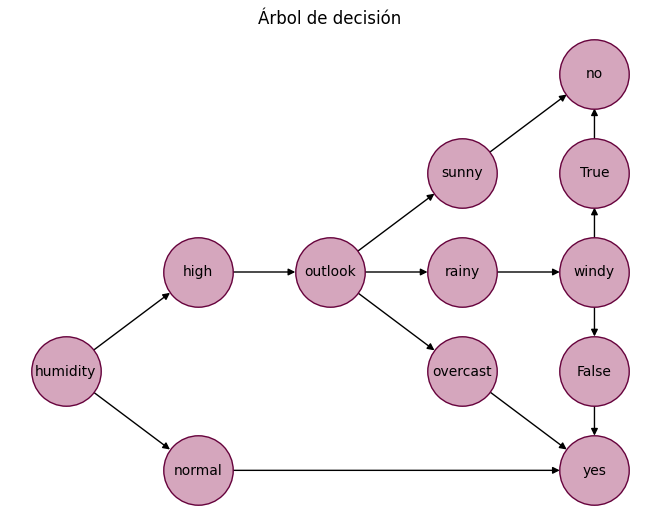

In [12]:
# Crear un grafo dirigido
G = nx.DiGraph()

# Agregar nodos y aristas
# Nodos:
G.add_node("humidity")
G.add_node("normal")
G.add_node("high")
G.add_node("overcast")
G.add_node("sunny")
G.add_node("rainy")
G.add_node("windy")
G.add_node("True")
G.add_node("False")
G.add_node("yes")
G.add_node("no")
# Aristas:
G.add_edge("humidity", "normal")
G.add_edge("normal", "yes")
G.add_edge("humidity", "high")
G.add_edge("high", "outlook")
G.add_edge("outlook", "overcast")
G.add_edge("outlook", "sunny")
G.add_edge("outlook", "rainy")
G.add_edge("rainy", "windy")
G.add_edge("windy", "True")
G.add_edge("windy", "False")
G.add_edge("overcast", "yes")
G.add_edge("sunny", "no")
G.add_edge("rainy", "windy")
G.add_edge("False", "yes")
G.add_edge("True", "no")

# Establecer las posiciones de los nodos
pos = {
    "humidity": (0, 4),  
    "normal": (1, 3),    
    "high": (1, 5),      
    "outlook": (2, 5),   
    "sunny": (3, 6),     
    "rainy": (3, 5),     
    "overcast": (3, 4),  
    "windy": (4, 5),     
    "True": (4, 6),      
    "False": (4, 4),     
    "yes": (4, 3),       
    "no": (4, 7),        
}

# Dibujar el grafo
nx.draw(
    G, # Grafo dirigido
    pos, # Posiciones
    with_labels=True, # Opción para colocar las etiquetas de los nodos
    node_size=2500, # Tamaño de los nodos
    node_color='#D5A6BD',  # Color de relleno (morado claro)
    edgecolors='#66023C',  # Color del borde (morado oscuro)
    font_size=10 # Tamaño de la letra
)

# Mostrar el grafo
plt.title("Árbol de decisión") # Título de la gráfica general
plt.show()

Tras haber obtenido el árbol de decisión para nuestros datos de entrenamiento donde cabe resaltar que no se usó la columna "temp" ya que no fue necesaria, se procede a dar uso del mismo y ver qué tanta precisión se obtiene. Para ello inicialmente se transforman los datos `X_test` en una matriz la cual contiene el indexado para un mejor uso en los condicionales, esto es guardado en la variable `data_array`. Junto a ello se crea un DataFrame llamado `Y_pred` el cual contendrá los resultados predichos por los condicionales en el mismo indexado que tiene `X_test`, funciona como los valores predichos tras emplear el modelo como se hace habitualmente con sklearn.

In [13]:
data_array = X_test.reset_index().values # Transformar en una matriz conteniendo el indexado
Y_pred = pd.DataFrame(columns=['play']) # Crear un DataFrame para guardar las etiquetas predichas por el árbol de decisión

Luego, se crean los diferentes condicionales tal como se pudo ver previamente y se guardan los resultados con el método `.loc[]` en el DataFrame `Y_pred`.

In [14]:
for i in range(X_test.shape[0]):
    if (data_array[i][3] == "normal"):
        Y_pred.loc[data_array[i][0]] = 'yes'
    elif (data_array[i][3] == "high"):
        if (data_array[i][1] == "overcast"):
            Y_pred.loc[data_array[i][0]] = 'yes'
        elif (data_array[i][1] == "sunny"):
            Y_pred.loc[data_array[i][0]] = 'no'
        elif (data_array[i][1] == "rainy"):
            if (data_array[i][4] == "False"):
                Y_pred.loc[data_array[i][0]] = 'yes'
            elif (data_array[i][4] == "False"):
                Y_pred.loc[data_array[i][0]] = 'no'

Se imprime el DataFrame `Y_pred` para visualizar los resultados obtenidos.

In [15]:
Y_pred

,play
9,yes
11,yes
0,no
12,yes
5,yes


Finalmente, usando métodos como `classification_report()` y `confusion_matrix()` se puede hacer un análisis de las métricas obtenidas por el modelo creado a mano. De la misma forma, usando `ConfusionMatrixDisplay()` se puede hacer una gráfica de la matriz de confusión con la cantidad de datos _Verdaderos Positivos (TP)_, _Falsos Negativos (FN)_, _Falsos Positivos (FP)_ y _Verdaderos Negativos (TN)_.

In [16]:
print(classification_report(Y_test, Y_pred)) # Reporte de las métricas

              precision    recall  f1-score   support

          no       1.00      0.50      0.67         2
         yes       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



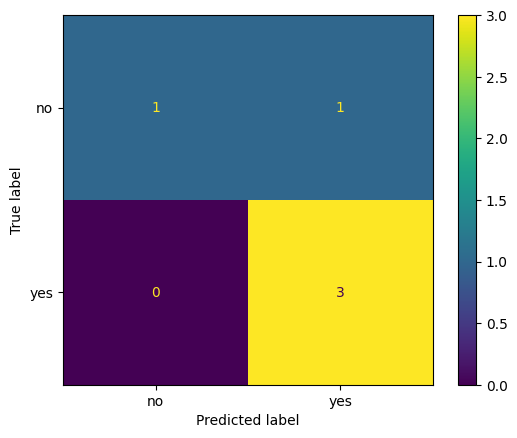

In [17]:
cm = confusion_matrix(Y_test, Y_pred) # Creación de la matriz de confusión
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes']) # Creación de la gráfica que muestra la matriz de confusión

cm_plot.plot()
plt.show()

Así, en conclusión nos podemos dar cuenta que obtuvimos unas muy buenas métricas en general, situación que también se evidencia en la matriz de confusión al haber tenido solo un valor que era en realidad "no" y fue clasificado como "yes" el cual se puede ver en la parte superior derecha de la gráfica.

---

## Implementación del algoritmo `DecisionTreeClassifier` dado por sklearn para los mismos datos

A continuación se hará todo exactamente igual solo que con el algoritmo dado por sklearn por lo que se reiniciará todo usando `%reset -f`.

In [18]:
%reset -f

Se vuelven a importar las librerías necesarias solo que ahora se implementan las necesarias para el algoritmo en sklearn.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder

Se usa un codificador para poder trabajar los datos categóricos, esto le permito a sklearn usar su algoritmo.

In [20]:
encoder = OneHotEncoder()

Se vuelve a importar el dataset `tennis.csv` en el DataFrame `tennis`. De una fez se realizan las separaciones en características y etiquetas.

In [21]:
tennis = pd.read_csv('./tennis.csv')

data_encoded = pd.get_dummies(tennis[['outlook', 'temp', 'humidity', 'windy']]) # Separación de las características
labels = tennis['play'] # Separación de las etiquetas

Se separa en los conjuntos de entrenamiento y test al igual que antes.

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(data_encoded, labels, test_size=0.3, random_state=42)

Se implementa el algoritmo dado por sklearn, lo que implica el instanciar el modelo en `clf`, entrenar el modelo con los datos de entrenamiento usando `.fit()` y poniendo a prueba el entrenamiento usando `.predict()` con los datos de test.

In [23]:
# Crear un clasificador de árbol de decisiones
clf = DecisionTreeClassifier()

# Entrenar el clasificador con los datos de entrenamiento
clf.fit(X_train, Y_train)

# Realizar predicciones en el conjunto de prueba
Y_pred = clf.predict(X_test)

Ahora, con ayuda de un método de sklearn llamado `plot_tree()` se puede visualizar el árbol generado por sklearn del cual ya se pueden comenzar a sacar conclusiones.

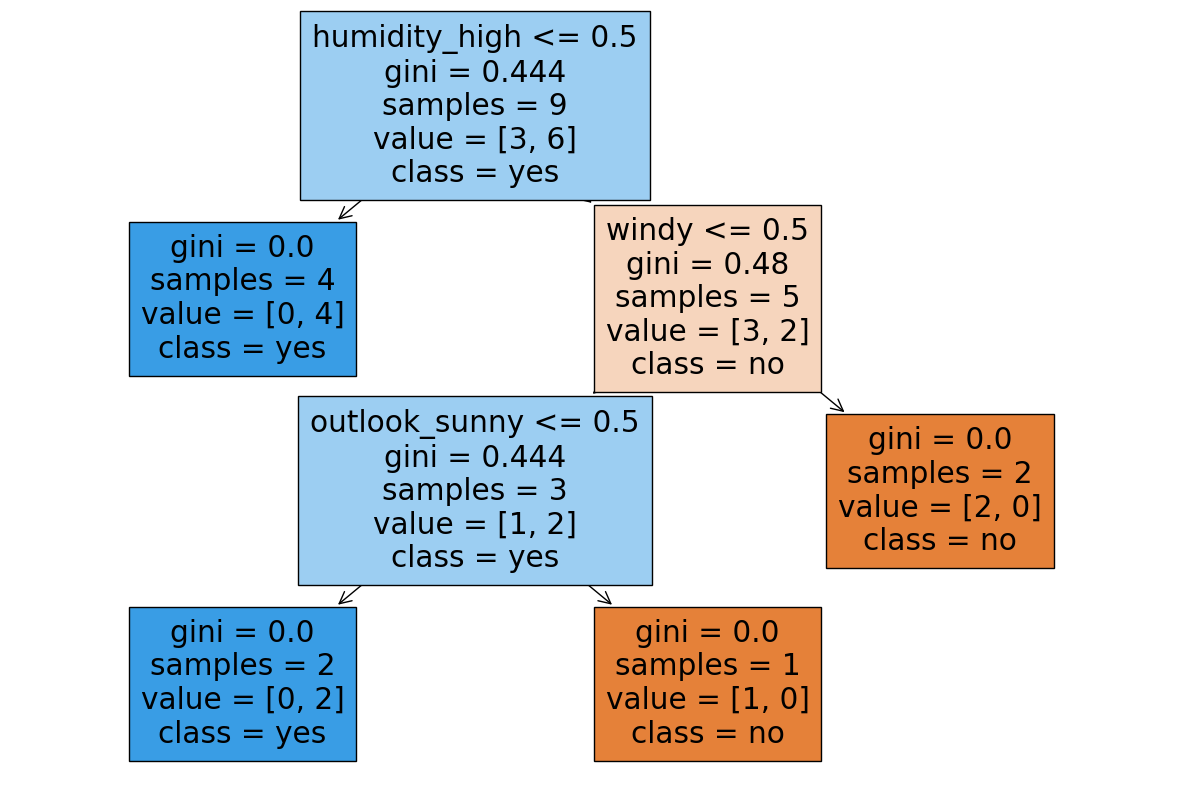

In [24]:
# Crear una figura para el árbol
plt.figure(figsize=(15, 10))

# Visualizar el árbol de decisión
plot_tree(clf, filled=True, feature_names=list(data_encoded.columns), class_names=['no', 'yes'])
plt.show()

Del árbol nos podemos dar cuenta que a diferencia del generado a mano, el algoritmo toma como segunda rama la columna "windy" para luego pasar a "outlook" y también nos podemos fijar en el parámetro de clasificación que usa. A diferencia de nosotros que usamos como parámetro la ganancia, sklearn usa el parámetro Gini, el cual viene definido como: $$\mathrm{Gini}(D) = 1 - \sum_{i=1}^{m} P_{i}^{2}$$ Lo que pudo haber sido el causal de obtener un árbol de decisión diferente. 

Para poder contrastar los resultados, usamos nuevamente los métodos previos para obtener las métricas.

In [25]:
print(classification_report(Y_test, Y_pred)) # Reporte de las métricas

              precision    recall  f1-score   support

          no       0.50      0.50      0.50         2
         yes       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



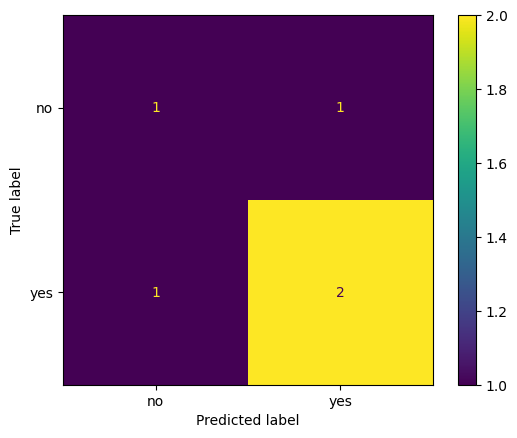

In [26]:
cm = confusion_matrix(Y_test, Y_pred) # Creación de la matriz de confusión
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes']) # Creación de la gráfica que muestra la matriz de confusión

cm_plot.plot()
plt.show()

Donde nos podemos dar cuenta que obtuvo una precisión general menor que nuestro modelo realizado a mano y que predijo dos valores erróneos, clasificó un "yes" donde iba un "no" y viceversa a diferencia de nuestro modelo que solo obtuvo un error.

## Conclusiones

Del anterior trabajo se puede concluir que en principio nuestro modelo realizado a mano para pocos datos tuvo una mayor precisión en la predicción de los mismos y esto puede ser por dos cosas, la primera es que quizá al nosotros conocer un poco los datos pudo haber un sobre entrenamiento por lo que funciona muy bien para los datos del dataset o también pudo haber sido el parámetro usado para la creación del árbol ya que se usaron las ganancias a diferencia de sklearn que usó Gini.

También es de destacar que este árbol de decisión creado por nosotros funciona únicamente para las configuraciones dadas en el `train_test_split`, es decir, con el tamaño de test del $30\%$ y también con una semilla fija de $42$, si se usan otras configuraciones no se garantiza que las funciones e incluso el árbol funcione de la misma forma, situación que no ocurre al usar sklearn ya que ellos ya poseen dicha generalidad.